# notebooks/task1_eda_analysis.ipynb


# # -------------------------------
# Task-1

# Load News Data

In [1]:
import pandas as pd

# Load CSV
df_news = pd.read_csv(r'C:\Users\Gebrekidan A\Desktop\kifya financial tech\newsData\Moves_challenge_week_1\raw_analyst_ratings.csv')

# Check columns and first rows
print(df_news.columns)
print(df_news.head())

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='object')
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10

# Descriptive Statistics

## Headline lengths:

In [ ]:

print("headline length")
df_news['headline_length'] = df_news['headline'].apply(len)
print(df_news['headline_length'].describe())


## Articles per publisher:

In [ ]:
publisher_counts = df_news['publisher'].value_counts()
print(publisher_counts)


## Publication trends:

In [2]:
# Convert 'date' to datetime
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')
# Articles per day
articles_per_day = df_news.groupby(df_news['date'].dt.date).size()
articles_per_day.head(10)

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
2011-05-02    9
2011-05-03    3
2011-05-05    3
2011-05-06    3
2011-05-07    2
dtype: int64

## Time Series Analysis

<Axes: title={'center': 'Articles per day'}, xlabel='date'>

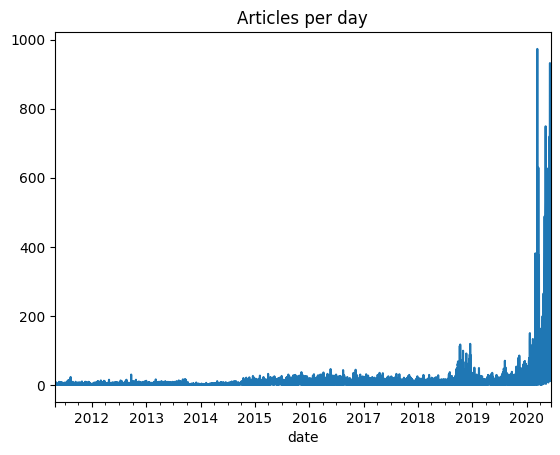

In [5]:
df_news['date'] = pd.to_datetime(df_news['date'])
df_news.set_index('date', inplace=True)
daily_counts = df_news.resample('D').size()
daily_counts.plot(title='Articles per day')



# Text Analysis (Topic Modeling / Keywords)

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=50)
X = vectorizer.fit_transform(df_news['headline'])
keywords = vectorizer.get_feature_names_out()
print("Top Keywords:", keywords)


Top Keywords: ['00' '10' '52' 'announces' 'bank' 'benzinga' 'buy' 'companies' 'company'
 'coverage' 'day' 'downgrades' 'earnings' 'energy' 'eps' 'est' 'estimate'
 'higher' 'initiates' 'lower' 'lowers' 'maintains' 'market' 'mid' 'moving'
 'neutral' 'new' 'price' 'pt' 'q1' 'q2' 'q3' 'q4' 'raises' 'reports'
 'sales' 'says' 'scheduled' 'sees' 'session' 'share' 'shares' 'stock'
 'stocks' 'target' 'trading' 'update' 'upgrades' 'vs' 'week']


# Publisher Analysis

In [4]:
# Top publishers
top_publishers = df_news['publisher'].value_counts().head(10)
print(top_publishers)


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64
